<a href="https://colab.research.google.com/github/ShivPrakashMishra/Aspire-AI/blob/main/CarMarketTrendAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv'
df = pd.read_csv(file_path)

# Display basic information
print('--- Dataset Info ---')
display(df.info())
print('\n--- Summary Statistics ---')
display(df.describe(include='all'))
print('\n--- First 5 Rows ---')
display(df.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


None


--- Summary Statistics ---


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000



--- First 5 Rows ---


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
# Checking for missing values
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values[missing_values > 0])

# Checking for duplicates
duplicates = df.duplicated().sum()
print(f'\nNumber of duplicate rows: {duplicates}')

Missing values per column:
Series([], dtype: int64)

Number of duplicate rows: 2


In [3]:
# 1. Remove duplicates
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

# 2. Feature Engineering: Calculate Car Age
# Assuming the current year is 2024 for analysis context,
# or we can use the max year in dataset as reference.
current_year = 2024
df['Car_Age'] = current_year - df['Year']

# 3. Quick check on categorical distributions
print('\nCategorical column counts:')
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    print(f'\n{df[col].value_counts()}')

display(df.head())

Shape after removing duplicates: (299, 9)

Categorical column counts:

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Owner
0    288
1     10
3      1
Name: count, dtype: int64


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


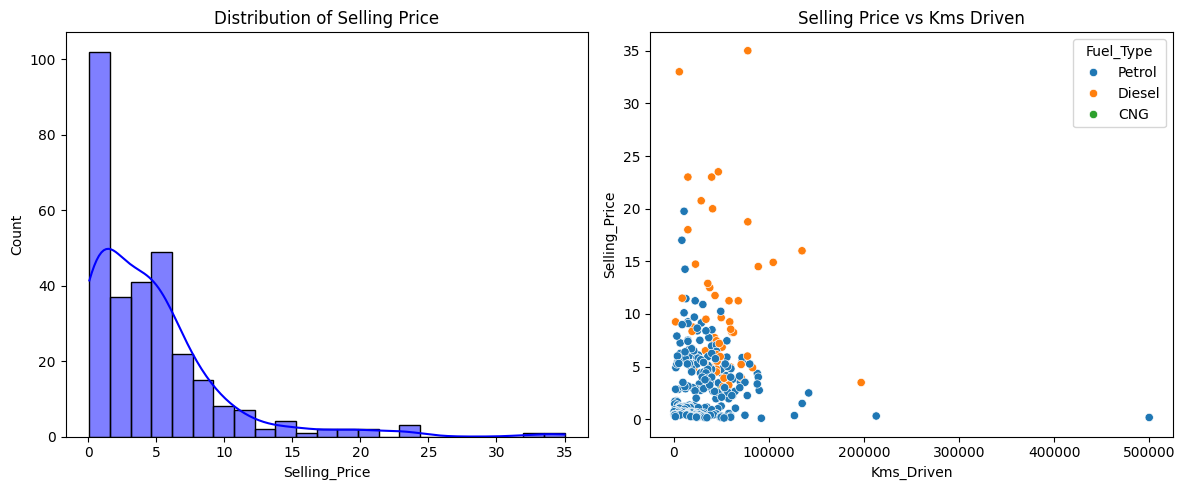

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Selling_Price'], kde=True, color='blue')
plt.title('Distribution of Selling Price')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price', hue='Fuel_Type')
plt.title('Selling Price vs Kms Driven')

plt.tight_layout()
plt.show()

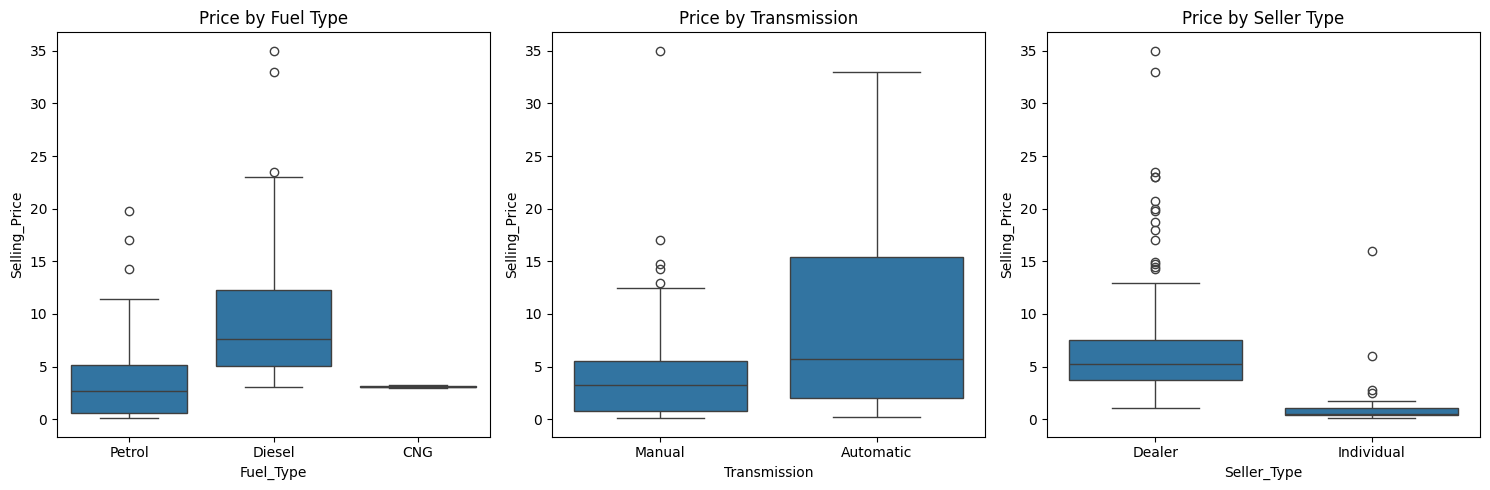

In [5]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title('Price by Fuel Type')

plt.subplot(1, 3, 2)
sns.boxplot(x='Transmission', y='Selling_Price', data=df)
plt.title('Price by Transmission')

plt.subplot(1, 3, 3)
sns.boxplot(x='Seller_Type', y='Selling_Price', data=df)
plt.title('Price by Seller Type')

plt.tight_layout()
plt.show()

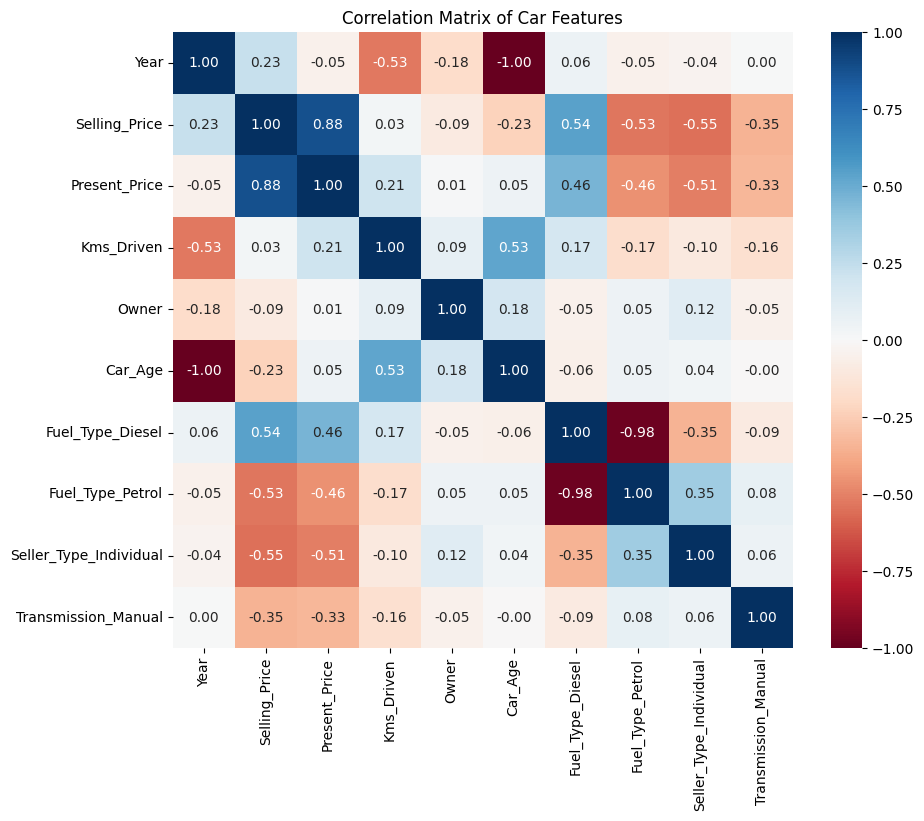

In [6]:
# Encoding categorical variables for correlation analysis
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

# Calculate correlation only for numeric columns to avoid string conversion errors
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Matrix of Car Features')
plt.show()